Training Teacher Network (Expert)...

Training Standalone Student Network (Baseline)...

Training Distilled Student Network (Proposed)...

FINAL TEST ACCURACY COMPARISON
Teacher Model (Expert)        : 29.0%
Standalone Student (Baseline) : 32.0%
Distilled Student (Proposed)  : 32.0%


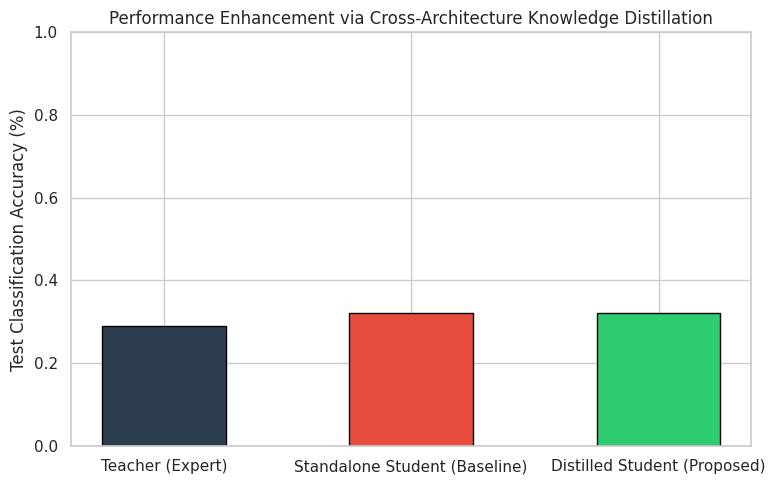

In [ ]:
# ==========================================
# Setup
# ==========================================

import os  # system tools
import warnings  # silence warnings
import numpy as np  # fast math
import torch  # deep learning
import torch.nn as nn  # neural layers
import torch.nn.functional as F  # activation functions
import torch.optim as optim  # weight adjusters
import matplotlib.pyplot as plt  # plot graphs
import seaborn as sns  # plot styling

warnings.filterwarnings('ignore')  # hide warnings

SEED = 42  # standard seed
torch.manual_seed(SEED)  # seed pytorch
np.random.seed(SEED)  # seed numpy

# ==========================================
# Architectures (Teacher vs Student)
# ==========================================

class TeacherNet(nn.Module):  # high-capacity network - TeacherNet: Deep network with two Conv layers (16→32 channels) and pooling - high capacity expert model that provides soft targets for distillation.
    def __init__(self, num_classes=3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),  # conv layer 1
            nn.ReLU(),  # activate
            nn.MaxPool2d(2),  # downsample
            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # conv layer 2
            nn.ReLU(),  # activate
            nn.MaxPool2d(2),  # downsample
            nn.Flatten()  # flatten outputs
        )
        self.fc = nn.Linear(32 * 8 * 8, num_classes)  # linear head

    def forward(self, x):
        return self.fc(self.conv(x))  # return logits

class StudentNet(nn.Module):  # lightweight network - StudentNet: Lightweight network with single Conv layer (8 channels) and aggressive pooling (4x) - small, fast model that learns from teacher's soft predictions.
    def __init__(self, num_classes=3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, padding=1),  # small conv
            nn.ReLU(),  # activate
            nn.MaxPool2d(4),  # aggressive downsample
            nn.Flatten()  # flatten outputs
        )
        self.fc = nn.Linear(8 * 8 * 8, num_classes)  # linear head

    def forward(self, x):
        return self.fc(self.conv(x))  # return logits

# ==========================================
# Knowledge Distillation Loss
# ==========================================

def distillation_loss(student_logits, teacher_logits, labels, T=3.0, alpha=0.5): # Distillation Loss: Combines soft loss (matches teacher's smoothed probabilities via KL divergence) and hard loss (matches true labels) - T controls softness, alpha balances both losses.
    # Soft target loss (matching smoothed probabilities via KL-Divergence)
    soft_loss = nn.KLDivLoss(reduction='batchmean')(
        F.log_softmax(student_logits / T, dim=1),
        F.softmax(teacher_logits / T, dim=1)
    ) * (T * T)  # rescale gradients by T^2

    # Hard target loss (matching standard true class indices)
    hard_loss = F.cross_entropy(student_logits, labels)

    return alpha * soft_loss + (1. - alpha) * hard_loss  # combined balance loss

# ==========================================
# Data Generation
# ==========================================

# Generate synthetic train and test images (3-channel 32x32)
X_train = torch.randn(200, 3, 32, 32)  # train inputs
y_train = torch.randint(0, 3, (200,))  # train labels (3 classes)
X_test = torch.randn(100, 3, 32, 32)  # test inputs
y_test = torch.randint(0, 3, (100,))  # test labels

# ==========================================
# Training Routines
# ==========================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # check processor
X_train, y_train = X_train.to(device), y_train.to(device)  # load device
X_test, y_test = X_test.to(device), y_test.to(device)  # load device

# 1. Train Teacher Model (Expert)
teacher = TeacherNet().to(device)  # load teacher
optimizer_t = optim.Adam(teacher.parameters(), lr=0.01)  # optimizer
criterion = nn.CrossEntropyLoss()  # label loss

print("Training Teacher Network (Expert)...")  # status log
teacher.train()  # train state
for epoch in range(25):  # loop epochs
    outputs = teacher(X_train)  # predict
    loss = criterion(outputs, y_train)  # loss
    optimizer_t.zero_grad()  # clean gradients
    loss.backward()  # backpropagation
    optimizer_t.step()  # update weights

# 2. Train Student Alone (Baseline)
student_alone = StudentNet().to(device)  # load baseline
optimizer_sa = optim.Adam(student_alone.parameters(), lr=0.01)  # optimizer

print("\nTraining Standalone Student Network (Baseline)...")  # status log
student_alone.train()  # train state
for epoch in range(25):  # loop epochs
    outputs = student_alone(X_train)  # predict
    loss = criterion(outputs, y_train)  # standard loss
    optimizer_sa.zero_grad()  # clean gradients
    loss.backward()  # backpropagation
    optimizer_sa.step()  # update weights

# 3. Train Student with Distillation (Proposed)
student_distilled = StudentNet().to(device)  # load proposed
optimizer_sd = optim.Adam(student_distilled.parameters(), lr=0.01)  # optimizer

teacher.eval()  # freeze teacher weights
print("\nTraining Distilled Student Network (Proposed)...")  # status log
student_distilled.train()  # train state
for epoch in range(25):  # loop epochs
    outputs = student_distilled(X_train)  # predict
    with torch.no_grad():  # freeze gradients
        teacher_logits = teacher(X_train)  # extract expert knowledge
    loss = distillation_loss(outputs, teacher_logits, y_train, T=3.0, alpha=0.7)  # distillation loss
    optimizer_sd.zero_grad()  # clean gradients
    loss.backward()  # backpropagation
    optimizer_sd.step()  # update weights

# ==========================================
# Evaluation & Visualizations
# ==========================================

teacher.eval()  # eval state
student_alone.eval()  # eval state
student_distilled.eval()  # eval state

with torch.no_grad():  # freeze gradients
    acc_t = (teacher(X_test).argmax(dim=1) == y_test).float().mean().item()  # score teacher
    acc_sa = (student_alone(X_test).argmax(dim=1) == y_test).float().mean().item()  # score baseline
    acc_sd = (student_distilled(X_test).argmax(dim=1) == y_test).float().mean().item()  # score distilled

print("\n=====================================")
print("FINAL TEST ACCURACY COMPARISON")
print("=====================================")
print(f"Teacher Model (Expert)        : {acc_t * 100:.1f}%")
print(f"Standalone Student (Baseline) : {acc_sa * 100:.1f}%")
print(f"Distilled Student (Proposed)  : {acc_sd * 100:.1f}%")
print("=====================================")

# Plot comparative bar chart
sns.set_theme(style="whitegrid")  # set theme
plt.figure(figsize=(8, 5))  # canvas size
models = ['Teacher (Expert)', 'Standalone Student (Baseline)', 'Distilled Student (Proposed)']
accuracies = [acc_t, acc_sa, acc_sd]
plt.bar(models, accuracies, color=['#2c3e50', '#e74c3c', '#2ecc71'], width=0.5, edgecolor='black')  # draw bars
plt.ylabel('Test Classification Accuracy (%)')  # y label
plt.ylim(0, 1.0)  # y bounds
plt.title('Performance Enhancement via Cross-Architecture Knowledge Distillation')  # plot title
plt.tight_layout()  # fit layouts
plt.show()  # display plot